# Week 2 Internship Task

## Baseline Regression Modeling

**Name:** Musfira Malik  
**Registration No:** AIMLB01-3456  
**Internship:** AI/ML Internship  

---

### Objective

The objective of this notebook is to build and evaluate baseline regression models to predict energy consumption (Usage_kWh) using the engineered dataset created in Part 1 (EDA & Feature Engineering). Multiple models will be trained, evaluated using MAE, RMSE, and R², validated using 5-fold cross-validation, and compared to select the best-performing baseline model.

## Step 1: Import Required Libraries

In this step, we import the libraries required for data handling, preprocessing, model training, evaluation, and visualization.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Engineered Dataset

The dataset used here is the engineered version produced in Part 1 (`steel_industry_engineered.csv`), which already contains all the additional features: `Hour`, `Month`, `Power_Factor_Ratio`, and `High_Load`, along with the original 11 columns.

In [4]:
# Load the engineered dataset
df = pd.read_csv(r"C:\Users\alsheikh computers\Desktop\Week2_EDA\data\steel_industry_engineered.csv")

print("Engineered dataset loaded successfully!")
print("Shape:", df.shape)

Engineered dataset loaded successfully!
Shape: (35039, 15)


## Step 3: Examine Dataset Structure

Before preprocessing, we re-examine the structure of the engineered dataset to confirm all expected columns are present and to check data types.

In [6]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")
print()
print(df.columns.tolist())
print()
df.info()

Number of Rows    : 35039
Number of Columns : 15

['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month', 'Power_Factor_Ratio', 'High_Load']

<class 'pandas.DataFrame'>
RangeIndex: 35039 entries, 0 to 35038
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35039 non-null  str    
 1   Usage_kWh                             35039 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35039 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35039 non-null  float64
 4   CO2(tCO2)                             35039 non-null  float64
 5   Lagging_Current_Power_Factor          35039 non-null  float64
 6   Leading_Current_Power_Factor  

## Step 4: Drop Date Column and Target-Leaking Features

Before training the models, we remove:

- **date** — the original datetime column is no longer needed since we already extracted `Hour` and `Month` from it in Part 1.
- **High_Load** — this feature was derived directly from `Usage_kWh` (75th percentile threshold), so keeping it would leak information about the target variable and artificially inflate model performance.

In [7]:
# Drop the original date column and the target-leaking High_Load feature
df_model = df.drop(columns=["date", "High_Load"])

print("Columns dropped successfully!")
print("Remaining columns:", df_model.columns.tolist())
print("Shape:", df_model.shape)

Columns dropped successfully!
Remaining columns: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Month', 'Power_Factor_Ratio']
Shape: (35039, 13)


## Step 5: Encode Categorical Variables

The dataset contains categorical columns: `WeekStatus`, `Day_of_week`, `Load_Type`, and `Month`. Since these categories do not have a natural numeric order (they are nominal, not ordinal), **one-hot encoding** is used instead of label encoding.

Label encoding would incorrectly imply an order between categories (e.g., "Monday < Tuesday < Wednesday"), which could mislead linear models like Linear Regression and Ridge. One-hot encoding avoids this by creating a separate binary column for each category, making it suitable for both linear and tree-based models.

In [8]:
# Identify categorical columns
categorical_cols = ["WeekStatus", "Day_of_week", "Load_Type", "Month"]

print("Categorical columns to encode:", categorical_cols)
print()

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("One-hot encoding completed!")
print("Shape before encoding:", df_model.shape)
print("Shape after encoding :", df_encoded.shape)

Categorical columns to encode: ['WeekStatus', 'Day_of_week', 'Load_Type', 'Month']

One-hot encoding completed!
Shape before encoding: (35039, 13)
Shape after encoding : (35039, 29)


### Preview of Encoded Dataset

We preview the encoded dataset to confirm the categorical columns were successfully converted into binary (0/1) columns.

In [9]:
df_encoded.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_Factor_Ratio,WeekStatus_Weekend,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Load_Type_Maximum_Load,Load_Type_Medium_Load,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


## Step 6: Train-Test Split

The dataset is split into training (80%) and testing (20%) sets using `random_state=42` to ensure reproducibility. The target variable is `Usage_kWh`.

In [10]:
# Define features (X) and target (y)
X = df_encoded.drop(columns=["Usage_kWh"])
y = df_encoded["Usage_kWh"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Training set shape: (28031, 28)
Testing set shape : (7008, 28)


## Step 7: Train Baseline Regression Models

Four models are trained on the training data: Linear Regression, Ridge Regression, Decision Tree Regressor, and Random Forest Regressor.

In [11]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Train each model
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

Linear Regression trained successfully!
Ridge Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


## Step 8: Evaluate Models on Test Set

For each trained model, we calculate Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) on the test set to compare performance.

In [12]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    
    print(f"--- {name} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print()

results_df = pd.DataFrame(results)
results_df

--- Linear Regression ---
MAE  : 5.4734
RMSE : 7.8014
R2   : 0.9456

--- Ridge Regression ---
MAE  : 4.2987
RMSE : 6.1595
R2   : 0.9661

--- Decision Tree ---
MAE  : 0.5420
RMSE : 1.5055
R2   : 0.9980

--- Random Forest ---
MAE  : 0.3353
RMSE : 1.0277
R2   : 0.9991



,Model,MAE,RMSE,R2
0,Linear Regression,5.473373,7.801418,0.945607
1,Ridge Regression,4.298725,6.159537,0.966093
2,Decision Tree,0.542025,1.505472,0.997974
3,Random Forest,0.335275,1.027666,0.999056


## Step 9: 5-Fold Cross-Validation

To check the stability and generalization of each model, 5-fold cross-validation is performed, and the mean RMSE across folds is reported.

In [13]:
cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    mean_rmse = -scores.mean()
    
    cv_results.append({
        "Model": name,
        "CV_Mean_RMSE": mean_rmse
    })
    
    print(f"{name}: Mean CV RMSE = {mean_rmse:.4f}")

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

Linear Regression: Mean CV RMSE = 8.7972
Ridge Regression: Mean CV RMSE = 6.9178
Decision Tree: Mean CV RMSE = 2.4926
Random Forest: Mean CV RMSE = 2.1100


,Model,CV_Mean_RMSE
0,Linear Regression,8.797204
1,Ridge Regression,6.917830
2,Decision Tree,2.492608
3,Random Forest,2.110033


## Step 10: Compare Test RMSE Across Models

A bar chart is used to visually compare the test RMSE of all four models.

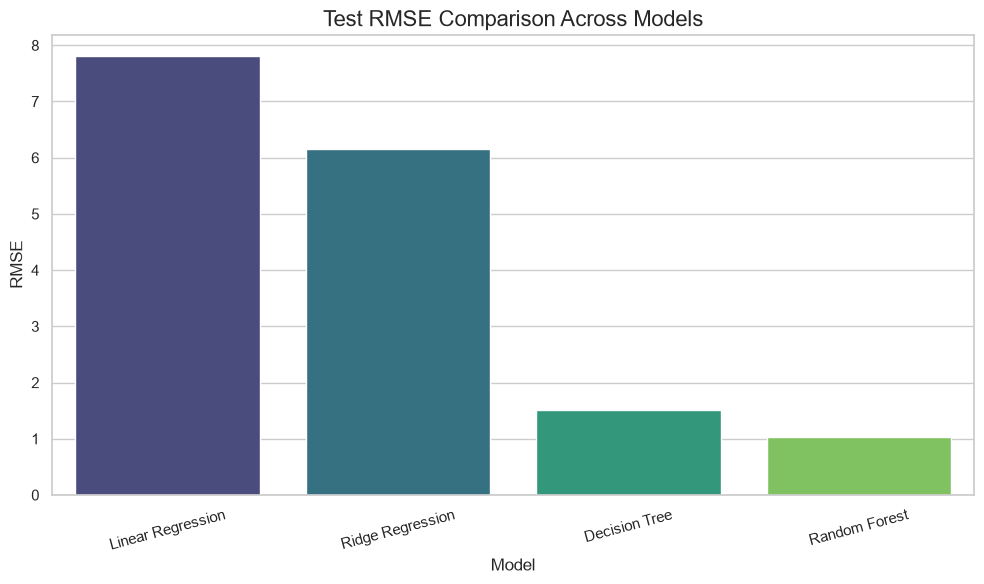

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    palette="viridis"
)

plt.title("Test RMSE Comparison Across Models", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("../assets/rmse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 11: Predicted vs Actual — Best Model

Based on the RMSE comparison, the best-performing model is identified, and a scatter plot of predicted vs actual values is created to visually assess its accuracy.

In [ ]:
# Identify best model (lowest test RMSE)
best_model_name = results_df.loc[results_df["RMSE"].idxmin(), "Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3, color="teal")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linestyle="--", linewidth=2
)

plt.title(f"Predicted vs Actual — {best_model_name}", fontsize=16)
plt.xlabel("Actual Usage_kWh", fontsize=12)
plt.ylabel("Predicted Usage_kWh", fontsize=12)

plt.tight_layout()
plt.savefig("../assets/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## Model Selection Summary

Four baseline regression models were trained and evaluated: Linear Regression, Ridge Regression, Decision Tree Regressor, and Random Forest Regressor.

Based on 5-fold cross-validation, the mean RMSE for each model was as follows:

- **Linear Regression:** 8.797
- **Ridge Regression:** 6.918
- **Decision Tree:** 2.493
- **Random Forest:** 2.110

The **Random Forest Regressor** achieved the lowest cross-validation RMSE (2.110), indicating it generalizes best across different subsets of the data. The Decision Tree performed reasonably well too (2.493) but is more prone to overfitting since it relies on a single tree, whereas Random Forest averages predictions across multiple trees, making it more stable and less sensitive to noise.

Linear Regression and Ridge Regression performed considerably worse, suggesting the relationship between features and energy consumption (Usage_kWh) is non-linear — which tree-based models capture more effectively.

**Model carried forward:** The **Random Forest Regressor** is selected as the final baseline model, as it achieved the lowest cross-validation RMSE and is expected to generalize best on unseen data.